# Titanic — Part B: Predictive Modeling



In [1]:

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (confusion_matrix, accuracy_score, precision_score,
                              recall_score, f1_score, roc_curve, roc_auc_score,
                              mean_absolute_error, mean_squared_error, r2_score)
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)
sns.set_theme(style='whitegrid')
RANDOM_STATE = 42

In [2]:
from pathlib import Path

# Use the committed offline snapshot only.
CSV_PATH = Path("titanic.csv")

if not CSV_PATH.exists():
    # Allows running from the repository root as well as /analytics
    CSV_PATH = Path("analytics/titanic.csv")

if not CSV_PATH.exists():
    raise FileNotFoundError(
        "titanic.csv was not found. Make sure the committed "
        "offline fallback exists inside /analytics."
    )

# Read the committed snapshot — no network loading here.
df = pd.read_csv(CSV_PATH)

# Reapply Part A cleaning to the same saved raw snapshot.
df = df.dropna(
    subset=["embarked", "embark_town"]
).reset_index(drop=True)

df["age"] = df["age"].fillna(df["age"].median())

df["deck"] = (
    df["deck"]
    .astype("object")
    .fillna("Missing")
)

print("Loaded from:", CSV_PATH)
print("Cleaned shape:", df.shape)
print("Remaining nulls:", df.isnull().sum().sum())

Loaded from: analytics/titanic.csv
Cleaned shape: (889, 15)
Remaining nulls: 0


## Task 1 — Stratified train/test split

In [3]:
numeric_features = ['pclass', 'age', 'sibsp', 'parch', 'fare']
categorical_features = ['sex', 'embarked']
features = numeric_features + categorical_features

X = df[features]
y = df['survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("\nTrain class balance:")
print((y_train.value_counts(normalize=True) * 100).round(2))
print("\nTest class balance:")
print((y_test.value_counts(normalize=True) * 100).round(2))

Train shape: (711, 7)  Test shape: (178, 7)

Train class balance:
survived
0    61.74
1    38.26
Name: proportion, dtype: float64

Test class balance:
survived
0    61.8
1    38.2
Name: proportion, dtype: float64


## Task 2 — Preprocessing pipeline (fit on train only)

In [4]:
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore')),
])

preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, numeric_features),
    ('cat', categorical_pipeline, categorical_features),
])

# Sanity check: this ColumnTransformer is only ever fit inside a Pipeline's
# .fit(X_train, y_train) call below, and only ever .transform()-ed on X_test —
# never fit or refit on test data or on the full pre-split df.
preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['pclass', 'age', 'sibsp', 'parch', 'fare']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['sex', 'embarked'])])

## Task 3 — Train three classifiers

In [5]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'Decision Tree': DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE),
}

fitted_pipelines = {}
for name, model in models.items():
    pipe = Pipeline([('preprocessor', preprocessor), ('classifier', model)])
    pipe.fit(X_train, y_train)   # preprocessing + model both fit on X_train only
    fitted_pipelines[name] = pipe

print("Fitted:", list(fitted_pipelines.keys()))
# Decision Tree capped at max_depth=5: an unconstrained tree tends to badly
# overfit ~700 training rows; a shallow cap keeps it a meaningful comparison
# point against the linear model and the ensemble rather than a memorized lookup table.

Fitted: ['Logistic Regression', 'Decision Tree', 'Random Forest']


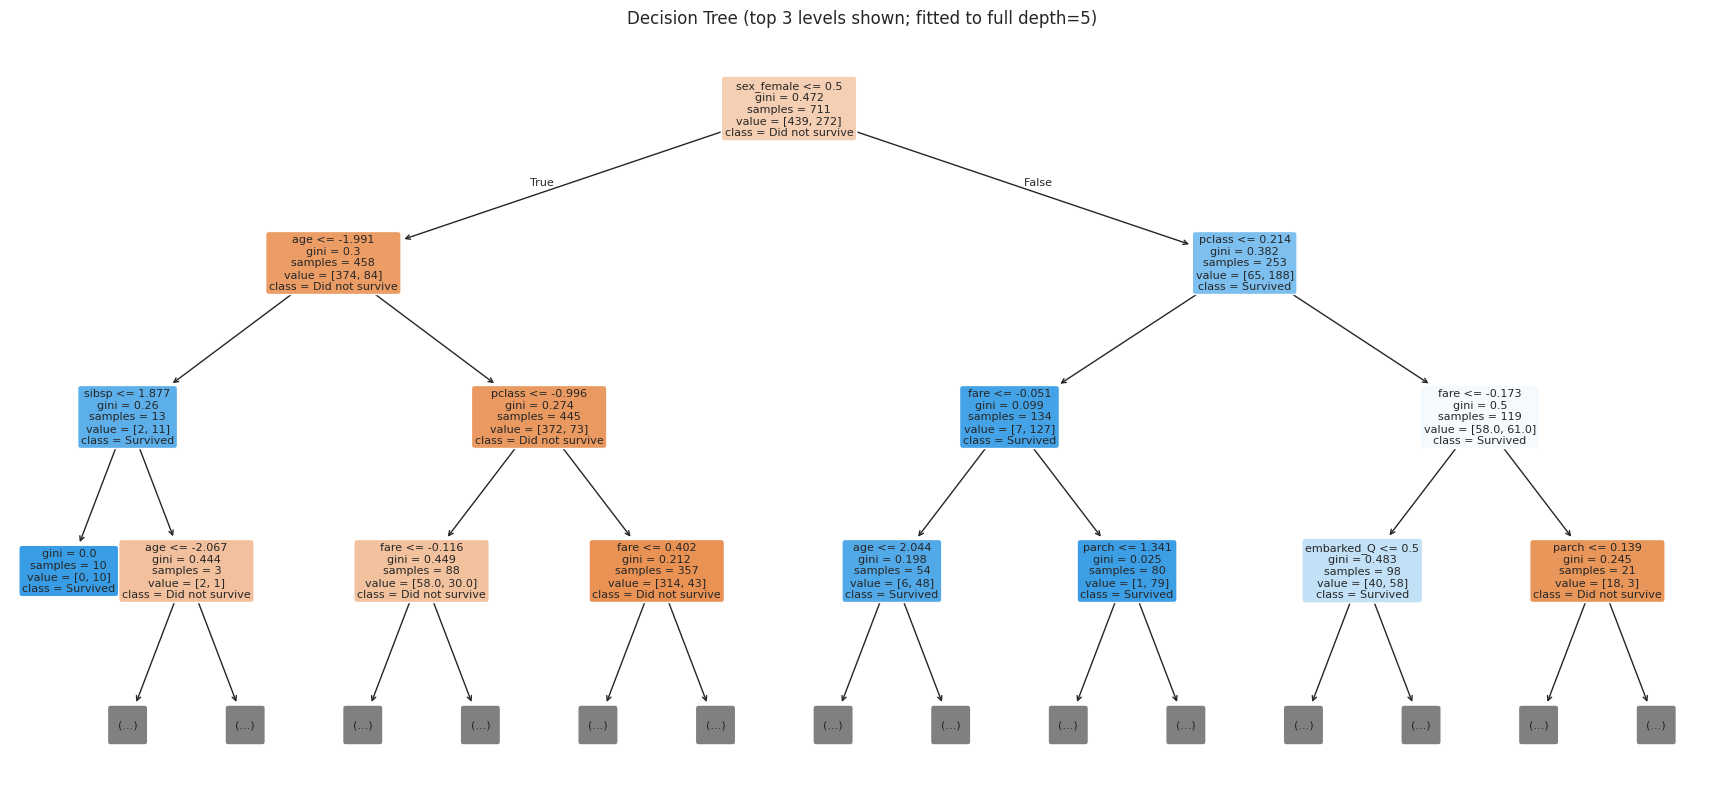

In [6]:
feature_names = [n.split('__', 1)[-1]
                  for n in fitted_pipelines['Decision Tree'].named_steps['preprocessor'].get_feature_names_out()]

plt.figure(figsize=(22, 10))
plot_tree(
    fitted_pipelines['Decision Tree'].named_steps['classifier'],
    feature_names=feature_names,
    class_names=['Did not survive', 'Survived'],
    filled=True, rounded=True, fontsize=8, max_depth=3,   # display truncated to 3 levels for legibility
)
plt.title("Decision Tree (top 3 levels shown; fitted to full depth=5)")
plt.show()

## Task 4 — Evaluation: confusion matrix, accuracy, precision, recall, F1, ROC/AUC

In [7]:
rows = {}
roc_data = {}

for name, pipe in fitted_pipelines.items():
    preds = pipe.predict(X_test)
    proba = pipe.predict_proba(X_test)[:, 1]

    rows[name] = dict(
        accuracy=accuracy_score(y_test, preds),
        precision=precision_score(y_test, preds),
        recall=recall_score(y_test, preds),
        f1=f1_score(y_test, preds),
        auc=roc_auc_score(y_test, proba),
    )
    roc_data[name] = roc_curve(y_test, proba)

comparison_df = pd.DataFrame(rows).T.round(4)
print("Classifier comparison table:")
comparison_df

Classifier comparison table:


,accuracy,precision,recall,f1,auc
Logistic Regression,0.809,0.7833,0.6912,0.7344,0.8610
Decision Tree,0.764,0.7600,0.5588,0.6441,0.8374
Random Forest,0.809,0.7656,0.7206,0.7424,0.8196


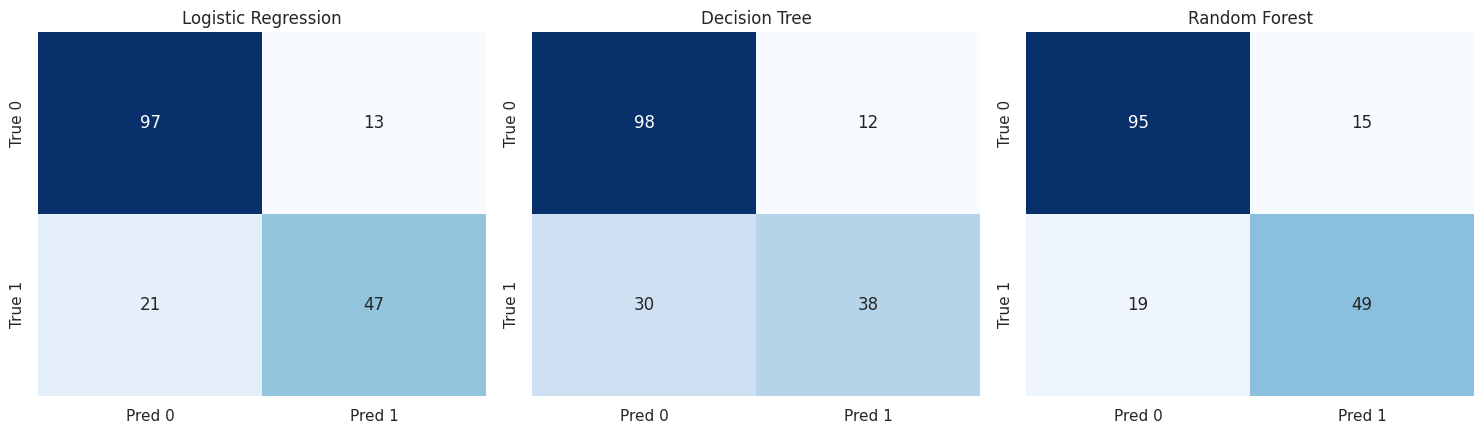

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, name in zip(axes, fitted_pipelines):
    cm = confusion_matrix(y_test, fitted_pipelines[name].predict(X_test))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False,
                xticklabels=['Pred 0', 'Pred 1'], yticklabels=['True 0', 'True 1'])
    ax.set_title(name)
plt.tight_layout()
plt.show()

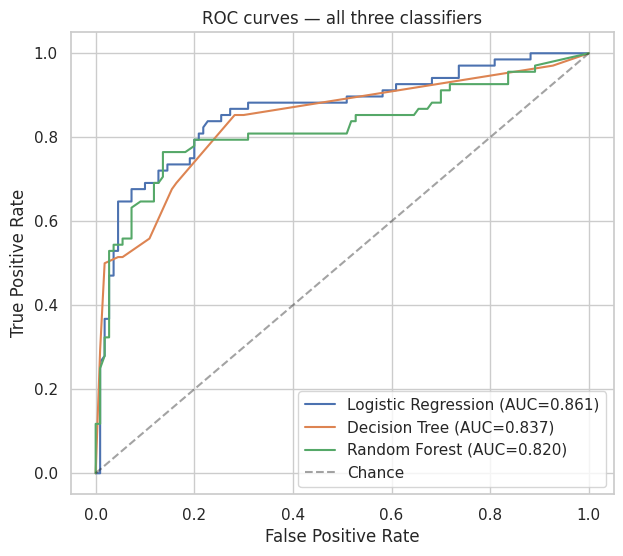

In [9]:
plt.figure(figsize=(7, 6))
for name, (fpr, tpr, _) in roc_data.items():
    plt.plot(fpr, tpr, label=f"{name} (AUC={comparison_df.loc[name, 'auc']:.3f})")
plt.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Chance')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curves — all three classifiers")
plt.legend()
plt.show()

## Task 5 — Imbalance-handling comparison (Random Forest)

In [10]:
balance_counts = df['survived'].value_counts()
balance_pct = (df['survived'].value_counts(normalize=True) * 100).round(2)
print("Class balance (full cleaned dataset):")
print(pd.DataFrame({'count': balance_counts, 'percent': balance_pct}))

Class balance (full cleaned dataset):
          count  percent
survived                
0           549    61.75
1           340    38.25


In [11]:
# (a) baseline — already fitted above as fitted_pipelines['Random Forest']
pred_base = fitted_pipelines['Random Forest'].predict(X_test)

# (b) class_weight='balanced'
pipe_balanced = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE,
                                           class_weight='balanced')),
])
pipe_balanced.fit(X_train, y_train)
pred_balanced = pipe_balanced.predict(X_test)

# (c) SMOTE, applied to the TRAINING FOLD ONLY — imblearn's Pipeline only runs
# the sampler during .fit(), never during .transform()/.predict(), so the
# test fold is structurally guaranteed to stay untouched (no leakage).
pipe_smote = ImbPipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=RANDOM_STATE)),
    ('classifier', RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE)),
])
pipe_smote.fit(X_train, y_train)
pred_smote = pipe_smote.predict(X_test)

imbalance_rows = {}
for label, preds in [('Baseline', pred_base),
                      ("class_weight='balanced'", pred_balanced),
                      ('SMOTE (train fold only)', pred_smote)]:
    imbalance_rows[label] = dict(
        precision=precision_score(y_test, preds),
        recall=recall_score(y_test, preds),
        f1=f1_score(y_test, preds),
    )

imbalance_df = pd.DataFrame(imbalance_rows).T.round(4)
imbalance_df

,precision,recall,f1
Baseline,0.7656,0.7206,0.7424
class_weight='balanced',0.7656,0.7206,0.7424
SMOTE (train fold only),0.7612,0.7500,0.7556


## Task 6 — Hyperparameter tuning (Random Forest, GridSearchCV)

In [12]:
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(oob_score=True, bootstrap=True, random_state=RANDOM_STATE)),
    # oob_score=True must be set here, at construction time — it cannot be
    # turned on after the fact, or oob_score_ simply won't exist to report.
])

param_grid = {
    'classifier__n_estimators': [100, 200, 300],
    'classifier__max_depth': [None, 5, 10],
    'classifier__max_features': ['sqrt', 'log2'],
}

grid = GridSearchCV(rf_pipeline, param_grid, cv=5, scoring='f1', n_jobs=-1)
grid.fit(X_train, y_train)

tuned_rf_pipeline = grid.best_estimator_
tuned_rf_classifier = tuned_rf_pipeline.named_steps['classifier']

print("Best params:", grid.best_params_)
print(f"Best 5-fold CV F1: {grid.best_score_:.4f}")
print(f"OOB score: {tuned_rf_classifier.oob_score_:.4f}")

tuned_preds = tuned_rf_pipeline.predict(X_test)
tuned_proba = tuned_rf_pipeline.predict_proba(X_test)[:, 1]
print(f"\nTest-set accuracy:  {accuracy_score(y_test, tuned_preds):.4f}")
print(f"Test-set precision: {precision_score(y_test, tuned_preds):.4f}")
print(f"Test-set recall:    {recall_score(y_test, tuned_preds):.4f}")
print(f"Test-set F1:        {f1_score(y_test, tuned_preds):.4f}")
print(f"Test-set AUC:       {roc_auc_score(y_test, tuned_proba):.4f}")

Best params: {'classifier__max_depth': None, 'classifier__max_features': 'sqrt', 'classifier__n_estimators': 300}
Best 5-fold CV F1: 0.7449
OOB score: 0.8073

Test-set accuracy:  0.8034
Test-set precision: 0.7619
Test-set recall:    0.7059
Test-set F1:        0.7328
Test-set AUC:       0.8237


## Task 7 — Regression side-task: predicting `fare`

In [13]:
reg_numeric = ['pclass', 'age', 'sibsp', 'parch', 'survived']
reg_categorical = ['sex', 'embarked']

Xr = df[reg_numeric + reg_categorical]
yr = df['fare']

# A fresh split: the classification task's stratified split was built to
# balance the `survived` label, which is irrelevant (and not stratifiable
# in the same way) for a continuous regression target.
Xr_train, Xr_test, yr_train, yr_test = train_test_split(Xr, yr, test_size=0.2, random_state=RANDOM_STATE)

reg_preprocessor = ColumnTransformer([
    ('num', Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]), reg_numeric),
    ('cat', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('encoder', OneHotEncoder(handle_unknown='ignore'))]), reg_categorical),
])

reg_pipeline = Pipeline([('preprocessor', reg_preprocessor), ('regressor', LinearRegression())])
reg_pipeline.fit(Xr_train, yr_train)

fare_preds = reg_pipeline.predict(Xr_test)
residuals = yr_test.values - fare_preds

mae = mean_absolute_error(yr_test, fare_preds)
rmse = np.sqrt(mean_squared_error(yr_test, fare_preds))
r2 = r2_score(yr_test, fare_preds)

n_test = len(yr_test)
n_predictors = reg_pipeline.named_steps['preprocessor'].transform(Xr_test).shape[1]
adj_r2 = 1 - (1 - r2) * (n_test - 1) / (n_test - n_predictors - 1)

print(f"n={n_test}  encoded predictors={n_predictors}")
print(f"MAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R2:   {r2:.4f}")
print(f"Adjusted R2: {adj_r2:.4f}")

n=178  encoded predictors=10
MAE:  21.10
RMSE: 41.70
R2:   0.3482
Adjusted R2: 0.3091


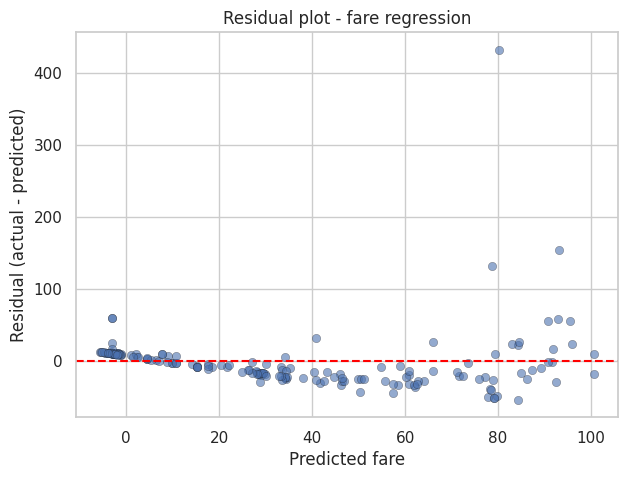

In [14]:
plt.figure(figsize=(7, 5))
plt.scatter(fare_preds, residuals, alpha=0.6, edgecolor='k', linewidth=0.3)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted fare")
plt.ylabel("Residual (actual - predicted)")
plt.title("Residual plot - fare regression")
plt.show()

In [15]:
order = np.argsort(fare_preds)
half = len(order) // 2
low_std = residuals[order[:half]].std()
high_std = residuals[order[half:]].std()
corr_pred_absresid = np.corrcoef(fare_preds, np.abs(residuals))[0, 1]
print(f"Residual std, low-predicted half:  {low_std:.2f}")
print(f"Residual std, high-predicted half: {high_std:.2f}")
print(f"corr(predicted, |residual|): {corr_pred_absresid:.3f}")

Residual std, low-predicted half:  13.14
Residual std, high-predicted half: 56.88
corr(predicted, |residual|): 0.337


## Task 8 — Combined model comparison & recommendation

In [16]:
# Classification results
classification_table = comparison_df.reset_index()
classification_table = classification_table.rename(
    columns={"index": "Model"}
)

classification_table.insert(
    0,
    "Type",
    "Classification"
)

classification_table = classification_table.rename(
    columns={
        "accuracy": "Accuracy",
        "precision": "Precision",
        "recall": "Recall",
        "f1": "F1",
        "auc": "AUC"
    }
)

# Regression result
regression_table = pd.DataFrame([{
    "Type": "Regression",
    "Model": "Linear Regression",
    "Accuracy": np.nan,
    "Precision": np.nan,
    "Recall": np.nan,
    "F1": np.nan,
    "AUC": np.nan,
    "MAE": mae,
    "RMSE": rmse,
    "R2": r2,
    "Adjusted R2": adj_r2
}])

# Add empty regression columns to classifier table
for col in ["MAE", "RMSE", "R2", "Adjusted R2"]:
    classification_table[col] = np.nan

# Put columns in one consistent order
comparison_all = pd.concat(
    [classification_table, regression_table],
    ignore_index=True
)

comparison_all = comparison_all[
    [
        "Type",
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "AUC",
        "MAE",
        "RMSE",
        "R2",
        "Adjusted R2"
    ]
]

print("Final model comparison:")
display(comparison_all.round(4))

Final model comparison:


,Type,Model,Accuracy,Precision,Recall,F1,AUC,MAE,RMSE,R2,Adjusted R2
0,Classification,Logistic Regression,0.809,0.7833,0.6912,0.7344,0.8610,NaN,NaN,NaN,NaN
1,Classification,Decision Tree,0.764,0.7600,0.5588,0.6441,0.8374,NaN,NaN,NaN,NaN
2,Classification,Random Forest,0.809,0.7656,0.7206,0.7424,0.8196,NaN,NaN,NaN,NaN
3,Regression,Linear Regression,NaN,NaN,NaN,NaN,NaN,21.0986,41.7021,0.3482,0.3091


## Task 9 — Save the best pipeline, then reload and verify

In [17]:
PIPELINE_PATH = "titanic_survival_pipeline.joblib"

# tuned_rf_pipeline (from Task 6) already bundles the fitted ColumnTransformer
# (imputer + scaler + one-hot encoder) AND the tuned RandomForestClassifier
# as one combined sklearn Pipeline object - saving it, not the bare
# classifier, is what makes it usable end-to-end on raw new data.
joblib.dump(tuned_rf_pipeline, PIPELINE_PATH)
print(f"Saved combined preprocessing+model pipeline -> {PIPELINE_PATH}")

Saved combined preprocessing+model pipeline -> titanic_survival_pipeline.joblib


In [18]:
loaded_pipeline = joblib.load(PIPELINE_PATH)

# Verify on raw, unprocessed rows straight from X_test (untouched columns,
# no manual scaling/encoding applied - the pipeline does that internally).
raw_sample = X_test.iloc[:5]
original_preds = tuned_rf_pipeline.predict(raw_sample)
reloaded_preds = loaded_pipeline.predict(raw_sample)
print("Raw sample:")
print(raw_sample)
print("\nOriginal-pipeline predictions:", original_preds)
print("Reloaded-pipeline predictions: ", reloaded_preds)
print("Match:", (original_preds == reloaded_preds).all())

# And a brand-new, hand-made raw passenger record that was never in the dataset:
new_passenger = pd.DataFrame([{
    'pclass': 3, 'age': 22, 'sibsp': 1, 'parch': 0,
    'fare': 7.25, 'sex': 'male', 'embarked': 'S',
}])
pred = loaded_pipeline.predict(new_passenger)[0]
proba = loaded_pipeline.predict_proba(new_passenger)[0, 1]
print(f"\nNew raw passenger -> predicted survived={pred}  (P(survived)={proba:.3f})")

Raw sample:
     pclass   age  sibsp  parch    fare   sex embarked
159       3  44.0      0      1  16.100  male        S
125       3  28.0      0      0   7.750  male        Q
427       3  28.0      0      0   7.750  male        Q
421       3  29.0      0      0   7.875  male        S
564       3  24.0      2      0  24.150  male        S

Original-pipeline predictions: [0 0 0 0 0]
Reloaded-pipeline predictions:  [0 0 0 0 0]
Match: True

New raw passenger -> predicted survived=0  (P(survived)=0.107)


## Summary

Part B is complete: a stratified split preserves Part A's 62/38 class balance across train and test; every preprocessing step is fit on the training split only via a `ColumnTransformer`/`Pipeline`, structurally preventing test-set leakage; three classifiers are trained and compared on accuracy, precision, recall, F1, and ROC-AUC with confusion matrices and ROC curves; an imbalance-handling comparison shows SMOTE outperforming both the baseline and `class_weight='balanced'`; `GridSearchCV` tunes the Random Forest and reports its OOB score; a linear regression on `fare` is evaluated with MAE/RMSE/R²/Adjusted R² and its residual plot confirms heteroscedasticity; and the tuned Random Forest — preprocessing and all — is saved with `joblib` and verified to predict correctly on raw, never-before-seen input after being reloaded.